# Stability Benchmark — full runnable pipeline (cache-first)

The same runnable pipeline as `pipeline.ipynb` (load -> generate -> test -> analyze), but scaled to
the **full benchmark** and **cache-first**: every expensive cell *loads the shipped result if it
already exists* and only calls the API when it is missing or you ask for a re-run.

So out of the box this runs in seconds with no API key (it reads the shipped 100-seed suite and the
four models' results). Change the config below to **re-run** or to **use a different dataset**:

| knob | effect |
|---|---|
| `DATASET` | which seed file in `data/<DATASET>.csv` to use (columns: `question`, `ground_truth`) |
| `N` | how many seeds to use (e.g. `5` for a quick test, `100` for the full set) |
| `REGEN_SUITE` | `True` = regenerate the test suite even if it is cached |
| `RERUN_MODELS` | list of run-names to re-run live; everything else loads from cache |


In [1]:
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATASET      = 'gsm8k_symbolic100'    # data/<DATASET>.csv  (your seeds: question, ground_truth)
N            = 100                     # seeds to use (5 = quick test, 100 = full benchmark)
REGEN_SUITE  = False                  # True -> regenerate the suite even if cached
RERUN_MODELS = []                     # e.g. ['gpt-4o-mini'] to re-run live; others load from cache

# models to report (run_name, provider, model_id). provider in {openai, groq, gemini}.
# o4-mini (reasoning) and phi4-mini (Ollama) ship as cached results; re-running them uses the
# dedicated scripts (run_sut_model.py / phi_cot_run.py), so leave them out of RERUN_MODELS.
SUT_MODELS = [
    ('o4-mini',          'openai', 'o4-mini'),
    ('gemini-2.5-flash', 'gemini', 'gemini-2.5-flash'),
    ('gpt-4o-mini',      'openai', 'gpt-4o-mini'),
    ('phi4-mini',        'ollama', 'phi4-mini'),
]
GEN_MODEL = 'gpt-4o-mini'             # model used for generation + the LLM gates/judges
THRESHOLD = 0.80
# ──────────────────────────────────────────────────────────────────────────────

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (ROOT / 'experiment' / 'data').exists():
    ROOT = ROOT / 'experiment'
OUT   = ROOT / 'output'
BENCH = OUT / 'benchmark' / DATASET; BENCH.mkdir(parents=True, exist_ok=True)
RUNS  = OUT / 'runs'
GEN_PATH = BENCH / 'generated.csv'

FAMILIES = ['Semantic Variation', 'Input Quality', 'Structural/Format', 'Context Interference',
            'Context Load', 'Conflict Instruction Stress', 'Knowledge Boundary']
TAG = {'Semantic Variation':'SV', 'Input Quality':'IQ', 'Structural/Format':'F',
       'Context Interference':'CI', 'Context Load':'CL', 'Conflict Instruction Stress':'CIS',
       'Knowledge Boundary':'KB'}
FAM_ORDER = ['SV', 'IQ', 'F', 'CI', 'CL', 'CIS', 'KB']
print(f'dataset={DATASET}  N={N}  regen={REGEN_SUITE}  rerun={RERUN_MODELS or "none (all cached)"}')

dataset=gsm8k_symbolic100  N=100  regen=False  rerun=none (all cached)


## Setup — API key (only needed if you generate or re-run)

If everything is cached you can skip this. Otherwise set `OPENAI_API_KEY` in your environment
(keys are never stored in the repo).

In [2]:
import os, sys
sys.path.insert(0, str(ROOT.parent)); sys.path.insert(0, str(ROOT))
api_key = os.environ.get('OPENAI_API_KEY')

# Fallback: repo-relative doc/Key_o.txt (git-ignored — see README "API keys").
if not api_key:
    _kf = ROOT.parent / 'doc' / 'Key_o.txt'
    if _kf.exists():
        api_key = _kf.read_text().strip().strip('"').strip("'")

client = None
if api_key:
    from openai import OpenAI
    client = OpenAI(api_key=api_key)
    print('LLM client ready.')
else:
    print('no API key set — fine as long as everything is cached.')

no API key set — fine as long as everything is cached.


## Step 1 — Load the seed problems

In [3]:
import pandas as pd
pd.set_option('display.max_colwidth', 70)

seeds = pd.read_csv(ROOT / 'data' / f'{DATASET}.csv').head(N).reset_index(drop=True)
print(f'{len(seeds)} seed problems from data/{DATASET}.csv')
seeds.head(3)

100 seed problems from data/gsm8k_symbolic100.csv


,original_id,local_row,question,answer,ground_truth
0,11,11,Toula went to the bakery and bought various types of pastries. She...,The total charge for the doughnuts was 3 x $68 = $<<3*68=204>>204....,694
1,20,20,I have 10 liters of orange drink that are two-thirds water and I w...,There are 15 x 3/5 = <<15*3/5=9>>9 liters of water from the 15 lit...,15
2,39,39,Dana can run at a rate of speed four times faster than she can wal...,"If Dana can skip at half the speed she can run, then she can run a...",18


## Step 2 — Generate the test suite (or load it)

If `output/benchmark/<DATASET>/generated.csv` exists and `REGEN_SUITE` is `False`, it is loaded.
Otherwise each seed is perturbed across 7 families x 5 levels and validity-gated — **resumable**,
so an interrupted run continues where it left off. This is the same code as `generate.py`.

In [4]:
import copy
from modules.data_intake import load_data
from modules.test_generator import generate_tests
from generator.llm_judge import LLMJudge
from run_utils import filter_ambiguous_ci

seeds.to_csv(OUT / 'run_base.csv', index=False)
intake = load_data(source='csv_upload', csv_path=str(OUT / 'run_base.csv'),
                   input_cols=['question'], output_cols=['ground_truth'],
                   type_overrides={'ground_truth': 'numeric'}, row_mode='all',
                   acceptance_threshold=THRESHOLD)

if GEN_PATH.exists() and not REGEN_SUITE:
    generated = pd.read_csv(GEN_PATH)
    print(f'loaded cached suite: {len(generated)} candidates from {GEN_PATH.relative_to(ROOT)}')
else:
    assert client is not None, 'generation needs an API key (see Setup)'
    judge = LLMJudge(client=client, model=GEN_MODEL)
    done = set(pd.read_csv(GEN_PATH)['Source Row'].unique()) if GEN_PATH.exists() else set()
    generated = pd.read_csv(GEN_PATH) if GEN_PATH.exists() else pd.DataFrame()
    for row_idx in range(len(intake.df)):
        if row_idx in done:
            continue
        ri = copy.copy(intake); ri.df = intake.df.iloc[[row_idx]].reset_index(drop=True)
        batch = generate_tests(test_names=FAMILIES, intake=ri, max_attempts=2,
                               llm_client=client, gen_model=GEN_MODEL, use_nli=True,
                               local_nli_gate=None, llm_judge=judge,
                               system_description='A math problem solver that answers grade school math questions')
        batch['Source Row'] = row_idx
        generated = pd.concat([generated, batch], ignore_index=True)
        generated.to_csv(GEN_PATH, index=False)
        print(f'  seed {row_idx}: +{len(batch)} candidates (total {len(generated)})')
    generated, _ = filter_ambiguous_ci(generated)
    generated.to_csv(GEN_PATH, index=False)
    print(f'generated suite saved to {GEN_PATH.relative_to(ROOT)}')

adm = generated[generated['Gate'] == True]
print(f'{len(generated)} candidates -> {len(adm)} admitted across {adm["Source Row"].nunique()} seeds')
adm['Category'].value_counts()

loaded cached suite: 5673 candidates from output/benchmark/gsm8k_symbolic100/generated.csv
5673 candidates -> 4473 admitted across 100 seeds


Category
Structural/Format              818
Input Quality                  751
Context Load                   737
Context Interference           605
Conflict Instruction Stress    600
Semantic Variation             573
Knowledge Boundary             389
Name: count, dtype: int64

## Step 3 — Test the models (or load their results)

For each model: if `output/runs/<name>__<DATASET>/eval.csv` exists and the name is **not** in
`RERUN_MODELS`, it is loaded. Otherwise the model is run on every admitted test (math families with
the solver prompt, Knowledge Boundary with the abstain prompt), scored, and cached. This is the same
code as `run_sut_model.py` (resumable per seed).

In [5]:
import json, time, re as _re
from modules.test_runner import run_tests
from modules.eval_all import eval_all
from registry.seed_kb import KB_EXPECTED_BEHAVIOR

PROVIDERS = {'openai': None,
             'groq':   'https://api.groq.com/openai/v1',
             'gemini': 'https://generativelanguage.googleapis.com/v1beta/openai/'}
KEYFILE   = {'openai': 'Key_o.txt', 'groq': 'Key_g.txt', 'gemini': 'Key_go.txt'}

MATH_PROMPT = ('You are a math problem solver. Given a grade school math question, solve it step by step '
               'and provide the final numerical answer.\n\n'
               'IMPORTANT: Your response must be ONLY a JSON object with this exact format:\n'
               '{"ground_truth": <number>}\n\n'
               'Where <number> is the final numerical answer (integer or decimal, no units, no $, no commas).')
KB_PROMPT   = ('Solve the grade-school math problem step by step. '
               'If the question has a false premise, an impossible or fictional scenario, made-up entities, '
               'or is missing information needed to solve it, do NOT invent an answer — briefly explain why '
               'it cannot be answered. Otherwise end with the final answer on its own line as a plain number '
               'only (no units, $, words, or commas):\n#### <number>')

def parse_math(raw):
    raw = raw.strip()
    for cand in [raw] + _re.findall(r'\{[^{}]*\}', raw):
        try:
            v = json.loads(cand)
            if isinstance(v, dict) and ('ground_truth' in v or 'answer' in v):
                return str(v.get('ground_truth', v.get('answer', '')))
        except Exception:
            pass
    m = _re.findall(r'####\s*\$?(-?[\d,]+\.?\d*)', raw)
    if m: return m[-1].replace(',', '')
    nums = _re.findall(r'-?[\d,]+\.?\d*', raw)
    return nums[-1].replace(',', '') if nums else raw

def make_client(provider):
    from openai import OpenAI
    if provider == 'openai' and client is not None:
        return client
    kf = ROOT.parent / 'doc' / KEYFILE[provider]
    assert kf.exists(), f'need {kf} (or OPENAI_API_KEY) to run a {provider} model'
    k = kf.read_text().strip().strip('"').strip("'")
    base = PROVIDERS[provider]
    return OpenAI(api_key=k, base_url=base) if base else OpenAI(api_key=k)

def make_sut(cl, model, prompt):
    def sut(fields):
        user = '\n'.join(f'{k.upper()}: {v}' for k, v in fields.items())
        r = cl.chat.completions.create(model=model, temperature=0.0, max_tokens=768,
                messages=[{'role':'system','content':prompt}, {'role':'user','content':user}])
        return {'ground_truth': parse_math((r.choices[0].message.content or '').strip())}
    return sut

def run_model(name, provider, model):
    """Run one model on all admitted tests, resumable per seed. Returns the scored eval DataFrame."""
    cl = make_client(provider)
    RUN_DIR = RUNS / f'{name}__{DATASET}'; RUN_DIR.mkdir(parents=True, exist_ok=True)
    resp_path = RUN_DIR / 'responses.csv'
    responses = pd.read_csv(resp_path) if resp_path.exists() else pd.DataFrame()
    done = set(responses['Source Row'].unique()) if len(responses) else set()
    for row_idx in sorted(generated['Source Row'].unique()):
        if row_idx in done:
            continue
        sub = generated[generated['Source Row'] == row_idx]
        ri = copy.copy(intake); ri.df = intake.df.iloc[[row_idx]].reset_index(drop=True)
        main = run_tests(generated_df=sub[sub['Category'] != 'Knowledge Boundary'],
                         sut=make_sut(cl, model, MATH_PROMPT), intake=ri, gate_only=True, n_baseline=3)
        kb   = run_tests(generated_df=sub[sub['Category'] == 'Knowledge Boundary'],
                         sut=make_sut(cl, model, KB_PROMPT), intake=ri, gate_only=True, n_baseline=0)
        res = pd.concat([main, kb], ignore_index=True); res['Source Row'] = row_idx
        responses = pd.concat([responses, res], ignore_index=True); responses.to_csv(resp_path, index=False)
        print(f'  [{name}] seed {row_idx}: +{len(res)} (total {len(responses)})')
    overrides = {'Knowledge Boundary': {'method':'llm_judge', 'expected_behavior':KB_EXPECTED_BEHAVIOR,
                                        'judge_model':'gpt-4o-mini'}}
    scored = eval_all(results_df=responses, intake=intake, overrides=overrides, client=make_client('openai'))
    scored.to_csv(RUN_DIR / 'eval.csv', index=False)
    return scored

print('runner ready')

runner ready


In [6]:
evals = {}
for name, provider, model in SUT_MODELS:
    eval_path = RUNS / f'{name}__{DATASET}' / 'eval.csv'
    if eval_path.exists() and name not in RERUN_MODELS:
        evals[name] = pd.read_csv(eval_path)
        print(f'loaded cached results: {name}')
    else:
        print(f'running {name} ({provider}:{model}) ...')
        evals[name] = run_model(name, provider, model)
print('models available:', list(evals))

loaded cached results: o4-mini
loaded cached results: gemini-2.5-flash
loaded cached results: gpt-4o-mini
loaded cached results: phi4-mini
models available: ['o4-mini', 'gemini-2.5-flash', 'gpt-4o-mini', 'phi4-mini']


## Step 4 — Analyze

Everything below is computed from the per-model `eval.csv` files, so it works for any dataset or
subset you ran above.

- **Collapse Point** — first level where a family's accuracy drops below τ = 0.80·acc(L0) (model-relative).
- **Stability** — magnitude-weighted output similarity per family.
- **Figure 1** — aggregate accuracy degradation by severity (one line per model).
- **Figure 2 (quadrants)** — each family at (x = mean perturbation magnitude, y = mean output
  stability). The horizontal line is a **constant 0.80** (the same correctness/stability cutoff used
  to define accuracy, so panels are directly comparable); the vertical line is the **mean perturbation
  magnitude** across the families (computed per panel, ≈0.24). Colours are keyed to families by the
  legend; the grey point is the unperturbed **Baseline**.

In [7]:
LEVELS = ['L1', 'L2', 'L3', 'L4', 'L5']

def per_family(eval_df):
    e = eval_df.copy()
    e['fam']     = e['Category'].map(TAG)
    e['sim']     = pd.to_numeric(e['Sim: outputs'], errors='coerce')
    e['scr']     = pd.to_numeric(e['Score'], errors='coerce')
    e['correct'] = e['sim'] >= THRESHOLD
    acc0 = e[e['Category'] == 'Temporal Consistency']['correct'].mean()
    sim0 = e[e['Category'] == 'Temporal Consistency']['sim'].mean()
    return e, acc0, sim0

# ---- Collapse Point (paper Table 5): first level with acc < 0.80*acc(L0) ----
cp_rows = []
for name, ev in evals.items():
    e, acc0, _ = per_family(ev); tau = 0.80 * acc0
    piv = e[e['fam'].notna()].pivot_table(index='fam', columns='Classified Level',
                                          values='correct', aggfunc='mean')
    cps = {f: ('—' if f not in piv.index else
               next((L for L in LEVELS if L in piv.loc[f].index and pd.notna(piv.loc[f][L])
                     and piv.loc[f][L] < tau), '—')) for f in FAM_ORDER}
    cp_rows.append({'model': name, 'acc(L0)': round(acc0, 3), **cps})
cp_df = pd.DataFrame(cp_rows).set_index('model')
print('Collapse Point per family (— = no collapse through L5):')
cp_df

Collapse Point per family (— = no collapse through L5):


,acc(L0),SV,IQ,F,CI,CL,CIS,KB
model,,,,,,,,
o4-mini,0.980,—,—,—,—,—,L5,L3
gemini-2.5-flash,0.943,—,—,—,—,—,L5,L3
gpt-4o-mini,0.887,—,—,—,L1,L3,L2,L3
phi4-mini,0.723,—,L2,—,—,—,L4,L5


In [8]:
# ---- Stability (paper Table 4): magnitude-weighted output similarity per family ----
def stability(e, mask):
    g = e[mask]; w = g['scr']; s = g['sim']; m = w.notna() & s.notna()
    return (s[m] * w[m]).sum() / w[m].sum() if (m.any() and w[m].sum() > 0) else float('nan')

stab_rows = []
for name, ev in evals.items():
    e, _, sim0 = per_family(ev)
    row = {'model': name, 'Baseline': round(sim0, 3)}
    for full, t in TAG.items():
        row[full] = round(stability(e, e['Category'] == full), 3)
    stab_rows.append(row)
stab_df = pd.DataFrame(stab_rows).set_index('model').T
print('Stability (magnitude-weighted output similarity):')
stab_df

Stability (magnitude-weighted output similarity):


model,o4-mini,gemini-2.5-flash,gpt-4o-mini,phi4-mini
Baseline,0.980,0.943,0.893,0.723
Semantic Variation,0.965,0.917,0.867,0.685
Input Quality,0.989,0.935,0.853,0.472
Structural/Format,0.985,0.946,0.812,0.732
Context Interference,0.966,0.947,0.683,0.729
Context Load,0.990,0.934,0.648,0.776
Conflict Instruction Stress,0.871,0.740,0.692,0.561
Knowledge Boundary,0.695,0.662,0.709,0.768


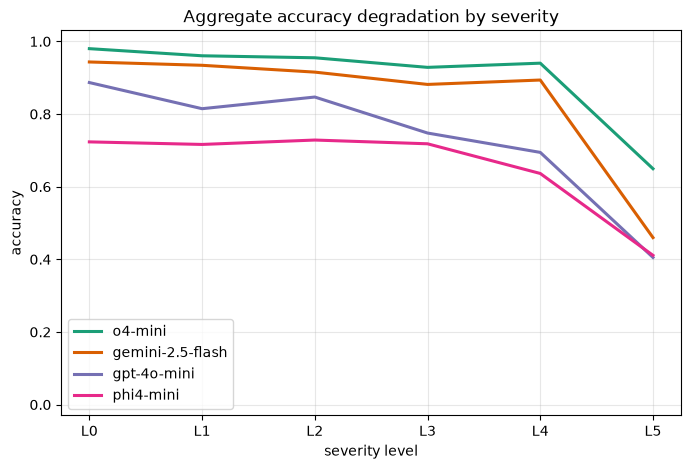

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ColorBrewer Dark2 — a standard professional qualitative palette for papers (plain lines, no markers)
MODEL_COLOR = {
    'o4-mini':          '#1b9e77',   # teal
    'gemini-2.5-flash': '#d95f02',   # burnt orange
    'gpt-4o-mini':      '#7570b3',   # slate purple
    'phi4-mini':        '#e7298a',   # magenta
}

# ---- Figure 1: aggregate accuracy degradation by severity, one line per model ----
ALL = ['L0'] + LEVELS
fig, ax = plt.subplots(figsize=(8, 5))
for name, ev in evals.items():
    e, acc0, _ = per_family(ev); st = e[e['fam'].notna()]
    curve = [acc0] + [st[st['Classified Level'] == L]['correct'].mean() for L in LEVELS]
    ax.plot(ALL, curve, lw=2.2, color=MODEL_COLOR.get(name, '0.4'), label=name)
ax.set_title('Aggregate accuracy degradation by severity')
ax.set_xlabel('severity level'); ax.set_ylabel('accuracy')
ax.set_ylim(-0.03, 1.03); ax.grid(alpha=0.3); ax.legend()
plt.show()

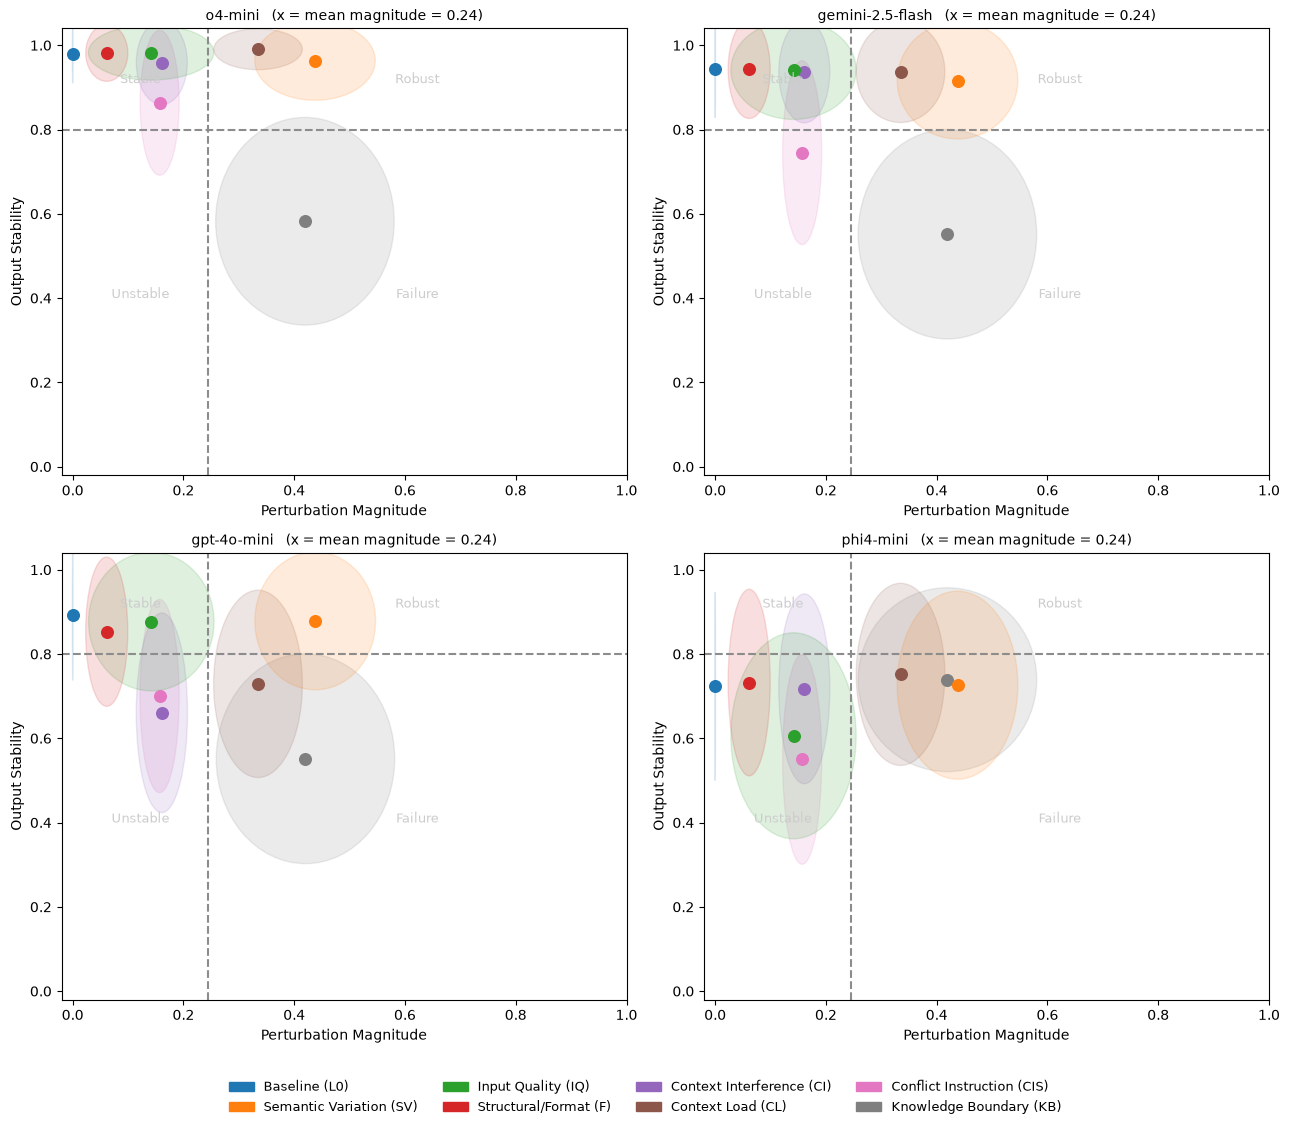

In [10]:
from matplotlib.patches import Ellipse, Patch

# ---- Figure 2: behavioral quadrants, one panel per model ----
# Each family sits at (x = mean Perturbation Magnitude, y = mean Output Stability).
# Dividers:
#   horizontal y = 0.80  (constant correctness/stability cutoff, same 0.80 used to define accuracy)
#   vertical   x = mean perturbation magnitude across the seven families (baseline excluded), computed per panel
CATS  = ['Temporal Consistency', 'Semantic Variation', 'Input Quality', 'Structural/Format',
         'Context Interference', 'Context Load', 'Conflict Instruction Stress', 'Knowledge Boundary']
LABEL = {'Temporal Consistency':'Baseline (L0)', 'Semantic Variation':'Semantic Variation (SV)',
         'Input Quality':'Input Quality (IQ)', 'Structural/Format':'Structural/Format (F)',
         'Context Interference':'Context Interference (CI)', 'Context Load':'Context Load (CL)',
         'Conflict Instruction Stress':'Conflict Instruction (CIS)', 'Knowledge Boundary':'Knowledge Boundary (KB)'}
_cmap = plt.colormaps.get_cmap('tab10')
COLOR = {c: _cmap(i) for i, c in enumerate(CATS)}     # fixed colour per family, consistent across panels

n = len(evals); cols = 2; rows = (n + 1) // 2
fig, axs = plt.subplots(rows, cols, figsize=(13, 5.6 * rows)); axs = np.array(axs).reshape(-1)
for ax, (name, ev) in zip(axs, evals.items()):
    d = ev.copy()
    if 'Gate' in d.columns: d = d[d['Gate'] == True]
    d['x'] = pd.to_numeric(d['Score'], errors='coerce')
    d['y'] = pd.to_numeric(d['Sim: outputs'], errors='coerce')
    d = d.dropna(subset=['x', 'y'])
    a = d.groupby('Category').agg(mx=('x','mean'), my=('y','mean'),
                                  sx=('x','std'), sy=('y','std')).fillna(0.0)
    ythr = THRESHOLD                                                     # constant 0.80 cutoff
    xthr = float(a.drop(index='Temporal Consistency', errors='ignore')['mx'].mean())  # mean magnitude
    for c, r in a.iterrows():
        col = COLOR.get(c, '0.5')
        ax.add_patch(Ellipse((r.mx, r.my), max(r.sx, 1e-3), max(r.sy, 1e-3), color=col, alpha=0.15))
        ax.scatter([r.mx], [r.my], color=col, s=70, zorder=3)
    ax.axhline(ythr, ls='--', color='0.55'); ax.axvline(xthr, ls='--', color='0.55')
    ax.text(xthr/2,     (ythr+1.02)/2, 'Stable',   color='0.8', ha='center', fontsize=9)
    ax.text((xthr+1)/2, (ythr+1.02)/2, 'Robust',   color='0.8', ha='center', fontsize=9)
    ax.text(xthr/2,     ythr/2,        'Unstable', color='0.8', ha='center', fontsize=9)
    ax.text((xthr+1)/2, ythr/2,        'Failure',  color='0.8', ha='center', fontsize=9)
    ax.set_xlim(-0.02, 1.0); ax.set_ylim(-0.02, 1.04)
    ax.set_title(f'{name}   (x = mean magnitude = {xthr:.2f})', fontsize=10)
    ax.set_xlabel('Perturbation Magnitude'); ax.set_ylabel('Output Stability')
for ax in axs[n:]: ax.axis('off')

# shared colour legend: which colour = which family
handles = [Patch(color=COLOR[c], label=LABEL[c]) for c in CATS]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()